https://livelmsip.s3.amazonaws.com/mediaFiles/2023/11/14195616/Module-5-Assignment-1-1.pdf

Problem Statement:
The task at hand involves classifying images of cats and dogs using a
Convolutional Neural Network (CNN). We have a dataset containing images of
cats and dogs and the objective is to train a CNN model to accurately predict the class of each image.

Objectives:

Data Preparation:

● Download and extract the cats vs. dogs dataset.

● Organize the dataset into a structured directory format suitable for TensorFlow’s ImageDataGenerator.

● Split the dataset into training and testing sets.

Data Augmentation and Preprocessing:
● Implement data augmentation techniques to increase the diversity of the
training dataset, aiding in the model's ability to generalize.

● Normalize the pixel values of the images for optimal model performance.

Model Building:

● Construct a Convolutional Neural Network using TensorFlow and Keras.

● The model should contain multiple convolutional layers, pooling layers, and fully connected layers.

Training:

● Compile the model and train it on the prepared dataset.

● Utilize categorical cross entropy as the loss function and stochastic
gradient descent as the optimizer.

● Train the model for a sufficient number of epochs to achieve good
performance

Evaluation:

● Evaluate the model's performance on the validation set during training to
monitor for overfitting.

● After training, assess the model's accuracy and make predictions on the
test set.

Prediction:

● Implement a system to make predictions on new images, categorizing
them as either cat or dog.

● The system should be able to take an image (or a batch of images),
preprocess it, and pass it through the mode for prediction.

In [7]:
# Setup and Data Preparation
import urllib.request
import zipfile
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Download dataset
url = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'
zip_path = 'cats_and_dogs_filtered.zip'
urllib.request.urlretrieve(url, zip_path)

# Extract dataset
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

# Directory setup
base_dir = 'cats_and_dogs_filtered'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')


In [8]:
# Data augmentation and normalization
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(150, 150), batch_size=32, class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    validation_dir, target_size=(150, 150), batch_size=32, class_mode='binary'
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [9]:
# Model Building
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
# Compile and train
model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=15,
    validation_data=val_generator,
    validation_steps=50
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
 63/100 ━━━━━━━━━━━━━━━━━━━━ 1:02 2s/step - accuracy: 0.5123 - loss: 0.6931

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.5094 - loss: 0.6932 - val_accuracy: 0.4990 - val_loss: 0.6928
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.5167 - loss: 0.6928 - val_accuracy: 0.5000 - val_loss: 0.6921
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.5172 - loss: 0.6925 - val_accuracy: 0.4990 - val_loss: 0.6915
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.5075 - loss: 0.6919 - val_accuracy: 0.5080 - val_loss: 0.6910
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.5373 - loss: 0.6916 - val_accuracy: 0.5180 - val_loss: 0.6904
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.5445 - loss: 0.6911 - val_accuracy: 0.5290 - val_loss: 0.6898
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.5385 - loss: 0.6907 - val_accuracy: 0.5260 - val_loss: 0.6891
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.5565 - loss: 0.6907 - val_accuracy: 0.527

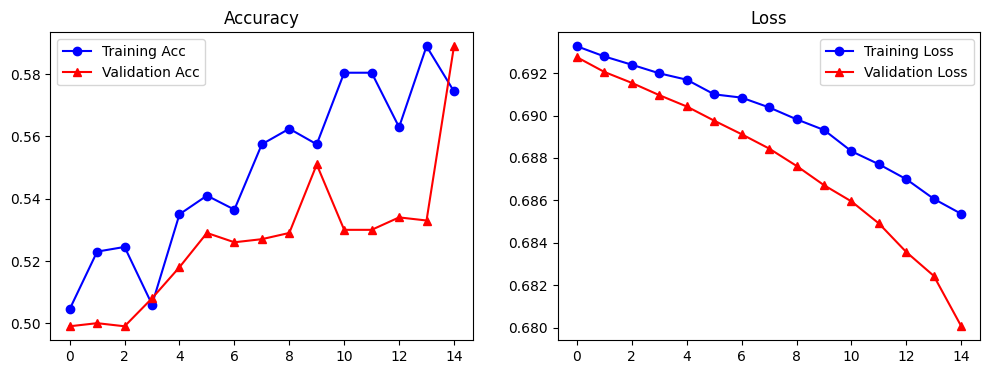

In [11]:
# Evaluate and plot accuracy
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Training Acc')
plt.plot(epochs, val_acc, 'r^-', label='Validation Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'r^-', label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()

Saving puppy-1047521_1280.jpg to puppy-1047521_1280.jpg


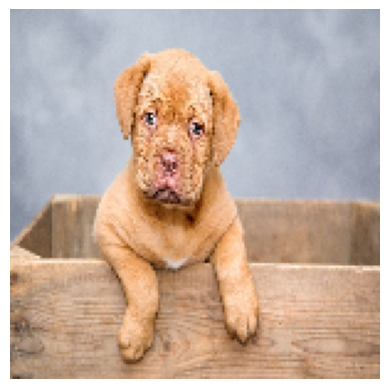

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
puppy-1047521_1280.jpg → **Dog** (0.54)


In [12]:
# Predict on new image
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

uploaded = files.upload()

for filename in uploaded.keys():
    img = load_img(filename, target_size=(150, 150))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    img_array = img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) / 255.0  # Normalize and add batch dim

    prediction = model.predict(img_array)
    if prediction[0][0] > 0.5:
        print(f"{filename} → **Dog** ({prediction[0][0]:.2f})")
    else:
        print(f"{filename} → **Cat** ({1 - prediction[0][0]:.2f})")

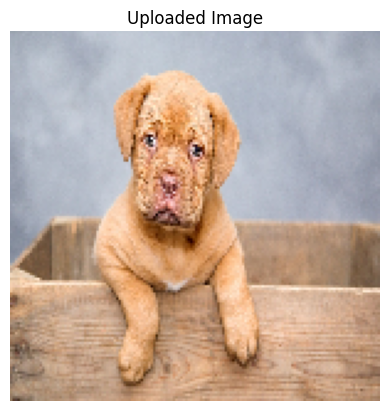

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
puppy-1047521_1280.jpg → **Dog** (53.60%)


In [14]:
from tensorflow.keras.utils import load_img, img_to_array

# Loop through uploaded files and predict
for filename in uploaded.keys():
    img = load_img(filename, target_size=(150, 150))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    img_array = img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) / 255.0
    prediction = model.predict(img_array)
    if prediction[0][0] > 0.5:
        print(f"{filename} → **Dog** ({prediction[0][0]*100:.2f}%)")
    else:
        print(f"{filename} → **Cat** ({(1 - prediction[0][0])*100:.2f}%)")